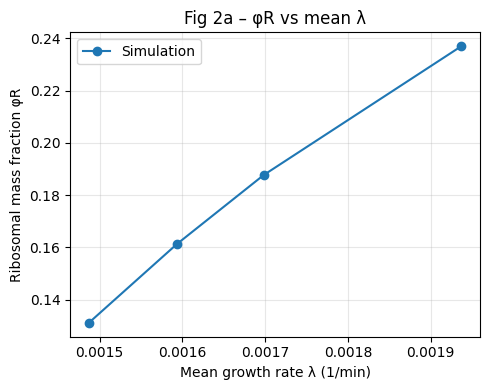

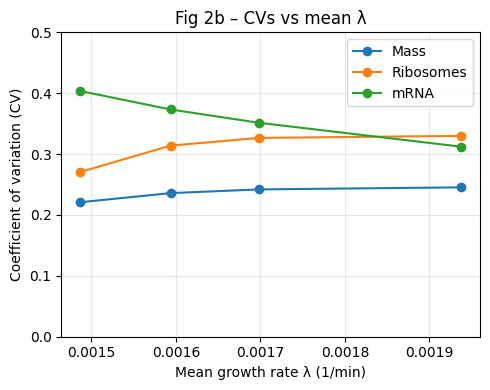

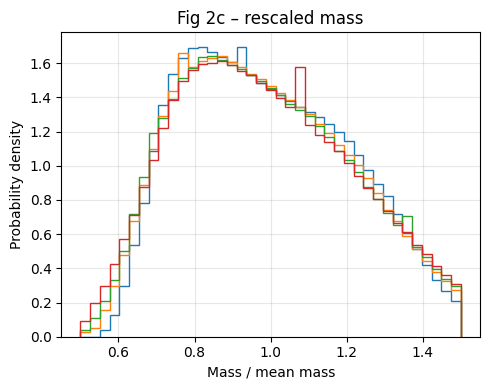

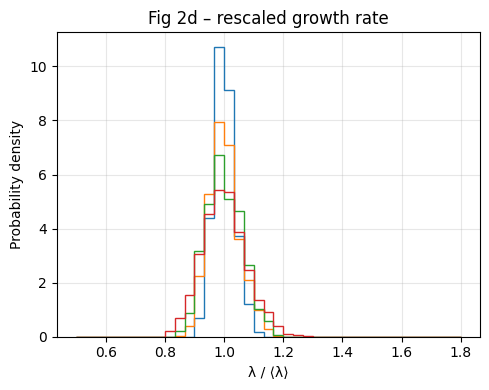

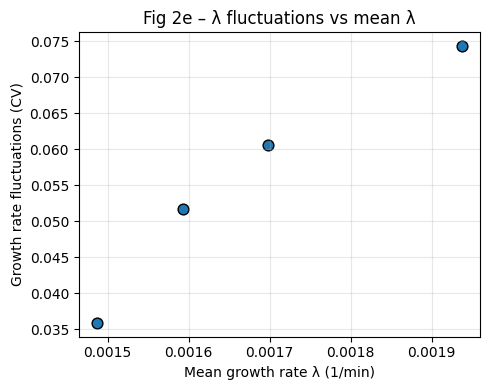

In [12]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# -------------------------------------------------------
# Files and constants
# -------------------------------------------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

# Parameters from your model
NR = 7549.0     # ribosomal protein "size"
NX = 300.0      # average non-ribosomal protein "size"
GMAX = 1260.0
KGAMMA = 7.0

BURN_IN_TIME = 1000.0   # minutes; adjust if you like

# -------------------------------------------------------
# Utilities
# -------------------------------------------------------
def load_arrow(path):
    """Read pyarrow file into DataFrame."""
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass     = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    mass = ribo_mass + non_ribo_mass
    return mass

def compute_phiR(df):
    """
    Total mass M(t) and ribosomal mass fraction φR(t),
    using the same formula as in the Julia mass(...) function:

    mass = nr * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
           + nx * (q + et + em)
    """
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass     = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    mass = ribo_mass + non_ribo_mass

    phiR = ribo_mass / mass
    return mass, phiR

def compute_lambda(df):
    """
    Growth rate λ(t) = translation flux / actual mass M(t).

    translation flux = gamma(a) * (# active ribosomes)
    where gamma(a) = GMAX * a / (KGAMMA + a)
    and "active" = rmr + rmt + rmm + rmq


    Calculate mass here so that it is calculated again at each time point
    gamma = GMAX*a/((KGAMMA*v1)/1e8 + a)
    """
    mass = compute_mass(df)
    a = df["a(t)"].to_numpy()
    v1 = 1e8/mass
    gamma = GMAX*a/(KGAMMA/v1 + a)

    active = (
        df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()

    ttrate = active * gamma
    lam = ttrate / mass
    return lam

def total_mrna(df):
    """Total mRNA (free): mm + mt + mq + mr."""
    return (
        df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]
    ).to_numpy()

# -------------------------------------------------------
# Collect statistics across ns
# -------------------------------------------------------
mean_lambda = []
mean_phiR   = []

cv_mass = []
cv_ribo = []
cv_mrna = []

rescaled_mass_all   = []
rescaled_lambda_all = []

mean_lambda_for_cv = []
growth_rate_cv      = []

for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    # mass and ribosomal fraction
    mass, phiR = compute_phiR(df)

    # growth rate using *actual* mass
    lam = compute_lambda(df)

    # total ribosomes (free + active) and mRNA
    ribo_tot = (
        df["r(t)"] + df["rmr(t)"] + df["rmt(t)"] +
        df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()
    mrna = total_mrna(df)

    # burn-in mask
    mask = t >= BURN_IN_TIME

    lam_ss   = lam[mask]
    mass_ss  = mass[mask]
    phiR_ss  = phiR[mask]
    ribo_ss  = ribo_tot[mask]
    mrna_ss  = mrna[mask]

    # ---- Fig 2a: φR vs mean λ ----
    mean_lambda.append(np.mean(lam_ss))
    mean_phiR.append(np.mean(phiR_ss))

    # ---- Fig 2b: CVs ----
    cv_mass.append(variation(mass_ss))
    cv_ribo.append(variation(ribo_ss))
    cv_mrna.append(variation(mrna_ss))

    # ---- Fig 2c: rescaled mass ----
    rescaled_mass_all.append(mass_ss / np.mean(mass_ss))

    # ---- Fig 2d: rescaled λ ----
    rescaled_lambda_all.append(lam_ss / np.mean(lam_ss))

    # ---- Fig 2e: CV of λ ----
    mean_lambda_for_cv.append(np.mean(lam_ss))
    growth_rate_cv.append(variation(lam_ss))

# -------------------------------------------------------
# Plot Fig 2a–e style panels
# -------------------------------------------------------

# (a) ribosomal fraction vs mean λ
plt.figure(figsize=(5,4))
plt.plot(mean_lambda, mean_phiR, "o-", label="Simulation")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Ribosomal mass fraction φR")
plt.title("Fig 2a – φR vs mean λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# (b) CVs of mass, ribosomes, mRNA vs λ
plt.figure(figsize=(5,4))
plt.ylim(0, 0.5)
plt.plot(mean_lambda, cv_mass, "o-", label="Mass")
plt.plot(mean_lambda, cv_ribo, "o-", label="Ribosomes")
plt.plot(mean_lambda, cv_mrna, "o-", label="mRNA")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Coefficient of variation (CV)")
plt.title("Fig 2b – CVs vs mean λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# (c) rescaled mass distributions
plt.figure(figsize=(5,4))
bins_mass = np.linspace(0.5, 1.5, 40)
for rescaled in rescaled_mass_all:
    plt.hist(rescaled, bins=bins_mass, histtype="step", density=True)
plt.xlabel("Mass / mean mass")
plt.ylabel("Probability density")
plt.title("Fig 2c – rescaled mass")
plt.grid(alpha=0.3)
plt.tight_layout()

# (d) rescaled growth rate distributions
plt.figure(figsize=(5,4))
bins_lam = np.linspace(0.5, 1.8, 40)
for rescaled in rescaled_lambda_all:
    plt.hist(rescaled, bins=bins_lam, histtype="step", density=True)
plt.xlabel("λ / ⟨λ⟩")
plt.ylabel("Probability density")
plt.title("Fig 2d – rescaled growth rate")
plt.grid(alpha=0.3)
plt.tight_layout()

# (e) CV of λ vs mean λ
plt.figure(figsize=(5,4))
plt.scatter(mean_lambda_for_cv, growth_rate_cv, s=60, edgecolor="k")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Growth rate fluctuations (CV)")
plt.title("Fig 2e – λ fluctuations vs mean λ")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


In [13]:
plt.figure(figsize=(5,4))
plt.plot(lam_ss[1:], lam_from_mass, "o", alpha=0.5)

plt.xlabel("λ from model (ttrate/mass)")
plt.ylabel("λ from d/dt log M")
plt.title("Check: growth-rate definition consistency")
plt.plot([0, 0.025], [0, 0.025], 'k--')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'lam_from_mass' is not defined

<Figure size 500x400 with 0 Axes>

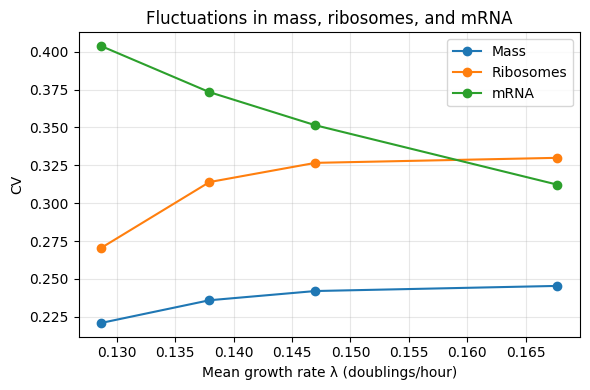

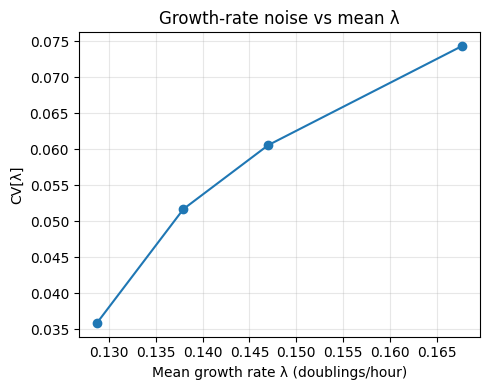

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# --------------------------------------------------
# 1. Load Arrow
# --------------------------------------------------
def load_arrow(fn):
    with pa.memory_map(fn, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# --------------------------------------------------
# 2. Model constants
# --------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 1260.0
KGAMMA = 7.0
BURN_IN = 1000.0       # minutes
MIN_TO_DLB = 60/np.log(2)

# --------------------------------------------------
# 3. Helpers to compute mass, ttrate, λ(t), mRNA
# --------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    nonribo_mass = NX * (q + et + em)
    return ribo_mass + nonribo_mass, ribo_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA * mass / 1e8 + a)
    active = (df["rmr(t)"] + df["rmt(t)"] +
              df["rmm(t)"] + df["rmq(t)"]).to_numpy()
    return active * gamma

def compute_lambda(df):
    mass, _ = compute_mass(df)
    ttrate = compute_ttrate(df, mass)
    lam = ttrate / mass          # 1/min
    lam_dlb = lam * MIN_TO_DLB   # convert to doublings/hour
    return lam_dlb, mass

def total_mrna(df):
    return (df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]).to_numpy()

# --------------------------------------------------
# 4. CV analysis for your 4 ns files
# --------------------------------------------------

FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

mean_lambda = []
cv_mass     = []
cv_ribo     = []
cv_mrna     = []
cv_lambda   = []

for ns, filename in FILES.items():
    df = load_arrow(filename)
    t = df["timestamp"].to_numpy()

    lam, mass = compute_lambda(df)
    mass, ribo_mass = compute_mass(df)
    mrna = total_mrna(df)

    mask = t >= BURN_IN

    lam_ss   = lam[mask]
    mass_ss  = mass[mask]
    ribo_ss  = ribo_mass[mask]
    mrna_ss  = mrna[mask]

    mean_lambda.append(np.mean(lam_ss))
    cv_mass.append(np.std(mass_ss) / np.mean(mass_ss))
    cv_ribo.append(np.std(ribo_ss) / np.mean(ribo_ss))
    cv_mrna.append(np.std(mrna_ss) / np.mean(mrna_ss))
    cv_lambda.append(np.std(lam_ss) / np.mean(lam_ss))

# --------------------------------------------------
# 5. Plot CVs (Fig 2b style)
# --------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(mean_lambda, cv_mass, "o-", label="Mass")
plt.plot(mean_lambda, cv_ribo, "o-", label="Ribosomes")
plt.plot(mean_lambda, cv_mrna, "o-", label="mRNA")
plt.xlabel("Mean growth rate λ (doublings/hour)")
plt.ylabel("CV")
plt.title("Fluctuations in mass, ribosomes, and mRNA")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Plot growth-rate CV (Fig 2e style)
# --------------------------------------------------
plt.figure(figsize=(5,4))
plt.plot(mean_lambda, cv_lambda, "o-", color="tab:blue")
plt.xlabel("Mean growth rate λ (doublings/hour)")
plt.ylabel("CV[λ]")
plt.title("Growth-rate noise vs mean λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


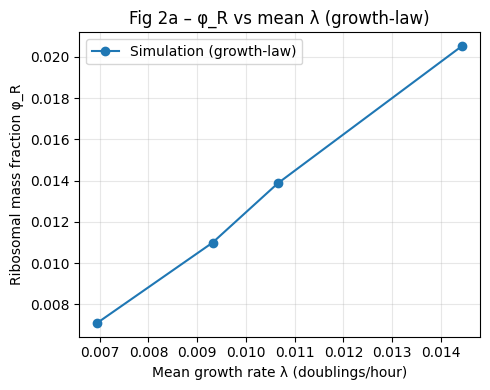

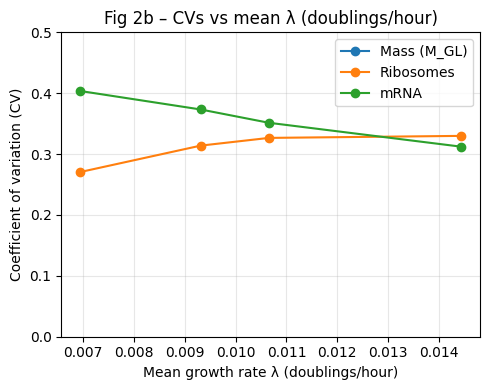

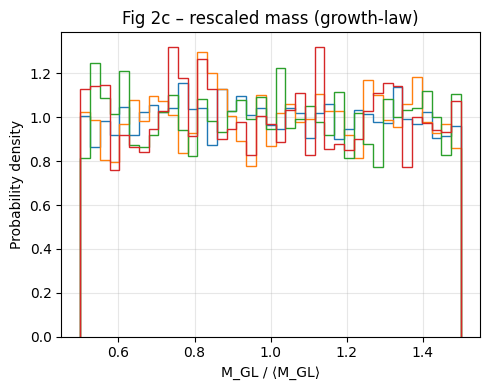

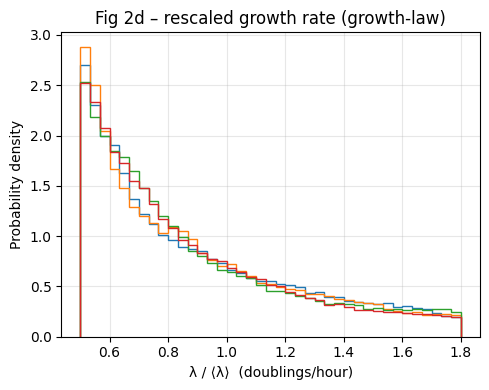

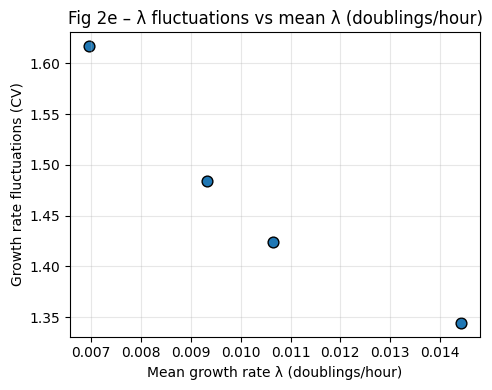

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# -------------------------------------------------------
# Files and constants
# -------------------------------------------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

# Parameters from your model (same as Julia)
NR = 7549.0     # ribosomal protein "size"
NX = 300.0      # average non-ribosomal protein "size"
GMAX = 1260.0
KGAMMA = 7.0

BURN_IN_TIME = 1000.0   # minutes

# helper constant: convert 1/min -> doublings/hour
MIN_TO_DLB_PER_HR = 60.0 / np.log(2.0)

# -------------------------------------------------------
# Utilities
# -------------------------------------------------------
def load_arrow(path):
    """Read pyarrow file into DataFrame."""
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_ribo_and_total_mass(df):
    """
    Ribosomal and total mass using the same form as in Julia:
    mass = nr * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
           + nx * (q + et + em)
    """
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass     = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    mass = ribo_mass + non_ribo_mass
    return ribo_mass, mass

def compute_ttrate(df, mass):
    """
    Translation rate ttrate(t) = (rmr + rmt + rmm + rmq) * gamma(a, mass)
    where (from Julia):

        v1 = 1e8 / mass
        gamma = gmax * a / (Kgamma / v1 + a)
              = gmax * a / (Kgamma * mass / 1e8 + a)
    """
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA * mass / 1e8 + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )
    ttrate = active * gamma
    return ttrate

def compute_gl_mass_and_lambda(t, ttrate, M0=None):
    """
    Construct growth-law mass M_GL(t) with dM_GL/dt = ttrate,
    and λ_GL(t) = ttrate / M_GL(t). λ_GL is in 1/min.
    """
    t = np.asarray(t)
    ttrate = np.asarray(ttrate)

    dt = np.diff(t)
    if M0 is None:
        M0 = 1.0

    M_GL = np.empty_like(ttrate)
    M_GL[0] = M0
    M_GL[1:] = M0 + np.cumsum(ttrate[:-1] * dt)

    M_GL[M_GL <= 0] = np.nan
    lam_GL = ttrate / M_GL
    return M_GL, lam_GL

def total_mrna(df):
    """Total free mRNA: mm + mt + mq + mr."""
    return (
        df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]
    ).to_numpy()

# -------------------------------------------------------
# Collect statistics across ns (using growth-law λ_GL, then convert to dbl/h)
# -------------------------------------------------------
mean_lambda_GL_dlb = []
mean_phiR_GL       = []

cv_mass = []
cv_ribo = []
cv_mrna = []

rescaled_mass_all   = []
rescaled_lambda_all = []

mean_lambda_for_cv_dlb = []
growth_rate_cv          = []

for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    # ribosomal and "full" total mass from original model
    ribo_mass, mass_full = compute_ribo_and_total_mass(df)

    # translation rate from original model
    ttrate = compute_ttrate(df, mass_full)

    # growth-law mass and λ (1/min)
    M_GL, lam_GL = compute_gl_mass_and_lambda(t, ttrate, M0=mass_full[0])

    # convert λ_GL to doublings/hour
    lam_GL_dlb = lam_GL * MIN_TO_DLB_PER_HR

    # growth-law ribosomal fraction (still using M_GL)
    phiR_GL = ribo_mass / M_GL

    # total ribosomes (free + active) and mRNA (for CVs)
    ribo_tot = (
        df["r(t)"]
        + df["rmr(t)"]
        + df["rmt(t)"]
        + df["rmm(t)"]
        + df["rmq(t)"]
    ).to_numpy()
    mrna = total_mrna(df)

    # burn-in mask
    mask = t >= BURN_IN_TIME

    lam_GL_dlb_ss = lam_GL_dlb[mask]
    M_GL_ss       = M_GL[mask]
    phiR_GL_ss    = phiR_GL[mask]
    ribo_ss       = ribo_tot[mask]
    mrna_ss       = mrna[mask]

    # remove NaNs
    valid = ~np.isnan(lam_GL_dlb_ss)
    lam_GL_dlb_ss = lam_GL_dlb_ss[valid]
    M_GL_ss       = M_GL_ss[valid]
    phiR_GL_ss    = phiR_GL_ss[valid]
    ribo_ss       = ribo_ss[valid]
    mrna_ss       = mrna_ss[valid]

    if lam_GL_dlb_ss.size == 0:
        print(f"Warning: no valid λ_GL after burn-in for ns = {ns}")
        continue

    # ---- Fig 2a: φR vs mean λ_GL (dbl/h) ----
    mean_lambda_GL_dlb.append(np.mean(lam_GL_dlb_ss))
    mean_phiR_GL.append(np.mean(phiR_GL_ss))

    # ---- Fig 2b: CVs of mass, ribosomes, mRNA vs λ_GL (dbl/h) ----
    # CV is invariant under scalar scaling, but we compute on dbl/h anyway.
    cv_mass.append(variation(M_GL_ss))
    cv_ribo.append(variation(ribo_ss))
    cv_mrna.append(variation(mrna_ss))

    # ---- Fig 2c: rescaled mass (growth-law mass) ----
    rescaled_mass_all.append(M_GL_ss / np.mean(M_GL_ss))

    # ---- Fig 2d: rescaled λ_GL (dbl/h) ----
    lam_scaled = lam_GL_dlb_ss / np.mean(lam_GL_dlb_ss)
    rescaled_lambda_all.append(lam_scaled)

    # ---- Fig 2e: CV of λ_GL (dbl/h) ----
    mean_lambda_for_cv_dlb.append(np.mean(lam_GL_dlb_ss))
    growth_rate_cv.append(variation(lam_GL_dlb_ss))

# -------------------------------------------------------
# Plot Fig 2a–e style panels using λ_GL in doublings/hour
# -------------------------------------------------------

# (a) ribosomal fraction vs mean λ_GL
plt.figure(figsize=(5,4))
plt.plot(mean_lambda_GL_dlb, mean_phiR_GL, "o-", label="Simulation (growth-law)")
plt.xlabel("Mean growth rate λ (doublings/hour)")
plt.ylabel("Ribosomal mass fraction φ_R")
plt.title("Fig 2a – φ_R vs mean λ (growth-law)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# (b) CVs of mass, ribosomes, mRNA vs λ_GL
plt.figure(figsize=(5,4))
plt.ylim(0, 0.5)
plt.plot(mean_lambda_GL_dlb, cv_mass, "o-", label="Mass (M_GL)")
plt.plot(mean_lambda_GL_dlb, cv_ribo, "o-", label="Ribosomes")
plt.plot(mean_lambda_GL_dlb, cv_mrna, "o-", label="mRNA")
plt.xlabel("Mean growth rate λ (doublings/hour)")
plt.ylabel("Coefficient of variation (CV)")
plt.title("Fig 2b – CVs vs mean λ (doublings/hour)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# (c) rescaled mass distributions
plt.figure(figsize=(5,4))
bins_mass = np.linspace(0.5, 1.5, 40)
for rescaled in rescaled_mass_all:
    plt.hist(rescaled, bins=bins_mass, histtype="step", density=True)
plt.xlabel("M_GL / ⟨M_GL⟩")
plt.ylabel("Probability density")
plt.title("Fig 2c – rescaled mass (growth-law)")
plt.grid(alpha=0.3)
plt.tight_layout()

# (d) rescaled growth-law λ distributions (doublings/hour)
plt.figure(figsize=(5,4))
bins_lam = np.linspace(0.5, 1.8, 40)
for rescaled in rescaled_lambda_all:
    plt.hist(rescaled, bins=bins_lam, histtype="step", density=True)
plt.xlabel("λ / ⟨λ⟩  (doublings/hour)")
plt.ylabel("Probability density")
plt.title("Fig 2d – rescaled growth rate (growth-law)")
plt.grid(alpha=0.3)
plt.tight_layout()

# (e) CV of λ_GL vs mean λ_GL (both in doublings/hour)
plt.figure(figsize=(5,4))
plt.scatter(mean_lambda_for_cv_dlb, growth_rate_cv, s=60, edgecolor="k")
plt.xlabel("Mean growth rate λ (doublings/hour)")
plt.ylabel("Growth rate fluctuations (CV)")
plt.title("Fig 2e – λ fluctuations vs mean λ (doublings/hour)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


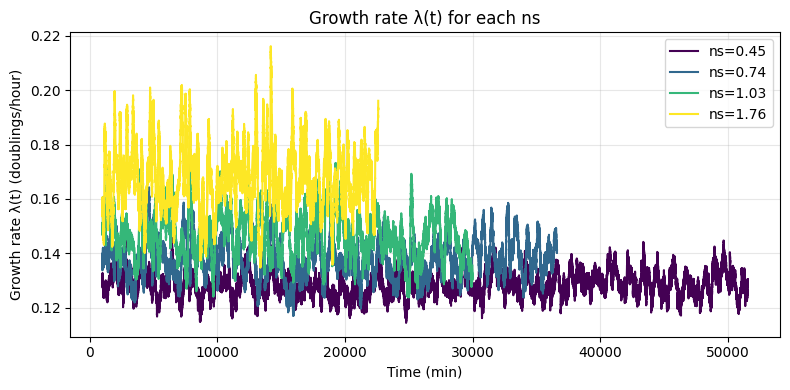

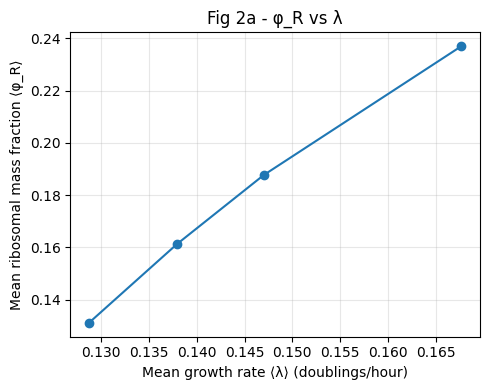

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# -------------------------------------------------------
# Files and constants
# -------------------------------------------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

NR = 7549.0   # ribosomal protein "size"
NX = 300.0    # average non-ribosomal protein "size"
GMAX = 1260.0
KGAMMA = 7.0

BURN_IN_TIME = 1000.0   # minutes
MIN_TO_DLB_PER_HR = 60.0 / np.log(2.0)   # 1/min -> doublings/hour

# -------------------------------------------------------
# Utilities
# -------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_ribo_and_total_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass     = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    mass = ribo_mass + non_ribo_mass
    return ribo_mass, mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA * mass / 1e8 + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )
    return active * gamma  # ttrate(t)

# -------------------------------------------------------
# Storage
# -------------------------------------------------------
ns_values        = []
t_ss_all         = []
lam_ss_all       = []   # λ(t) in dbl/h after burn-in, per ns
phiR_mean_all    = []   # mean ribosomal mass fraction per ns
lambda_mean_all  = []   # mean λ per ns (dbl/h)

# -------------------------------------------------------
# Main loop
# -------------------------------------------------------
for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    ribo_mass, mass_full = compute_ribo_and_total_mass(df)
    ttrate = compute_ttrate(df, mass_full)

    # original λ in 1/min, then convert to doublings/hour
    lam = ttrate / mass_full
    lam_dlb = lam * MIN_TO_DLB_PER_HR

    # ribosomal fraction (using full mass)
    phiR = ribo_mass / mass_full

    # align lengths defensively
    N = min(len(t), len(lam_dlb), len(phiR))
    t       = t[:N]
    lam_dlb = lam_dlb[:N]
    phiR    = phiR[:N]

    # burn-in
    mask = t >= BURN_IN_TIME
    t_ss      = t[mask]
    lam_ss    = lam_dlb[mask]
    phiR_ss   = phiR[mask]

    # drop NaNs (just in case)
    valid = (~np.isnan(lam_ss)) & (~np.isnan(phiR_ss))
    t_ss    = t_ss[valid]
    lam_ss  = lam_ss[valid]
    phiR_ss = phiR_ss[valid]

    if t_ss.size == 0:
        print(f"Warning: no valid data after burn-in for ns = {ns}")
        continue

    ns_values.append(ns)
    t_ss_all.append(t_ss)
    lam_ss_all.append(lam_ss)

    lambda_mean_all.append(np.mean(lam_ss))
    phiR_mean_all.append(np.mean(phiR_ss))

# -------------------------------------------------------
# 1) Growth rate over time, one line per ns
# -------------------------------------------------------
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_values)))
plt.figure(figsize=(8,4))
for ns, t_ss, lam, col in zip(ns_values, t_ss_all, lam_ss_all, COLORS):
    plt.plot(t_ss, lam, color=col, label=f"ns={ns}")


plt.xlabel("Time (min)")
plt.ylabel("Growth rate λ(t) (doublings/hour)")
plt.title("Growth rate λ(t) for each ns")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 2) φ_R vs mean growth rate (classic growth-law style)
# -------------------------------------------------------
plt.figure(figsize=(5,4))
# plt.xlim(0,0.2)
# plt.ylim(0,0.25)
plt.plot(lambda_mean_all, phiR_mean_all, "o-")
plt.xlabel("Mean growth rate ⟨λ⟩ (doublings/hour)")
plt.ylabel("Mean ribosomal mass fraction ⟨φ_R⟩")
plt.title("Fig 2a - φ_R vs λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



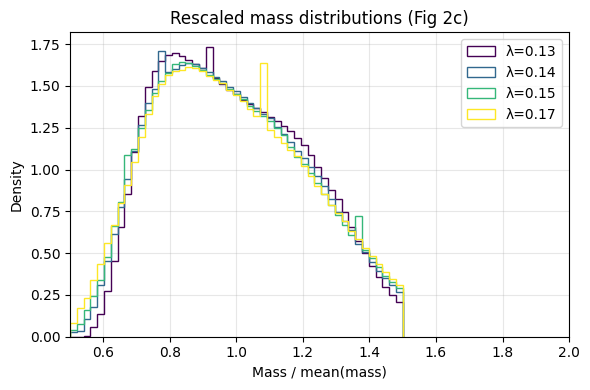

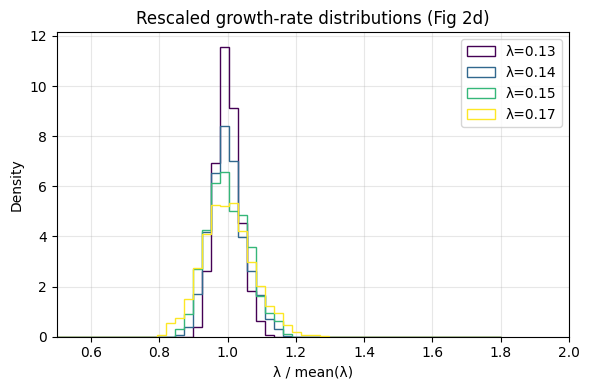

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Files
# -------------------------------------------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

NR = 7549.0
NX = 300.0
GMAX = 1260.0
KGAMMA = 7.0

BURN_IN = 1000.0
MIN_TO_DLB = 60/np.log(2)

# -------------------------------------------------------
# Helpers
# -------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    nonribo_mass = NX * (q + et + em)
    return ribo_mass + nonribo_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA * mass / 1e8 + a)
    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )
    return active * gamma

# -------------------------------------------------------
# STORAGE
# -------------------------------------------------------
lambda_mean_all = []            # <-- we use this for labels
mass_rescaled_all = []
lam_rescaled_all  = []

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
for ns, fn in FILES.items():
    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)
    lam = ttrate / mass
    lam_dlb = lam * MIN_TO_DLB

    # equal length
    N = min(len(t), len(mass), len(lam_dlb))
    t = t[:N]; mass = mass[:N]; lam_dlb = lam_dlb[:N]

    # burn-in
    mask = t >= BURN_IN
    mass_ss = mass[mask]
    lam_ss  = lam_dlb[mask]

    # clean
    good = (~np.isnan(mass_ss)) & (~np.isnan(lam_ss))
    mass_ss = mass_ss[good]
    lam_ss = lam_ss[good]

    # compute means for labeling
    lambda_mean = np.mean(lam_ss)
    lambda_mean_all.append(lambda_mean)

    # rescaled
    mass_rescaled_all.append(mass_ss / lambda_mean)     
    mass_rescaled_all[-1] = mass_ss / np.mean(mass_ss)  

    lam_rescaled_all.append(lam_ss / lambda_mean)

# -------------------------------------------------------
# COLOURS BASED ON GROWTH RATE
# -------------------------------------------------------
lambda_sorted_idx = np.argsort(lambda_mean_all)
COLORS = plt.cm.viridis(np.linspace(0,1,len(lambda_mean_all)))

# -------------------------------------------------------
# PLOT C — Rescaled mass
# -------------------------------------------------------
plt.figure(figsize=(6,4))
bins = np.linspace(0.5, 1.5, 50)

for idx, col in zip(lambda_sorted_idx, COLORS):
    rescaled = mass_rescaled_all[idx]
    lam_mean = lambda_mean_all[idx]
    plt.hist(rescaled, bins=bins, histtype="step", density=True,
             color=col, label=f"λ={lam_mean:.2f}")

plt.xlabel("Mass / mean(mass)")
plt.ylabel("Density")
plt.xlim(0.5, 2)
plt.title("Rescaled mass distributions (Fig 2c)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# PLOT D — Rescaled growth rate
# -------------------------------------------------------
plt.figure(figsize=(6,4))
bins = np.linspace(0.5, 1.8, 50)

for idx, col in zip(lambda_sorted_idx, COLORS):
    rescaled = lam_rescaled_all[idx]
    lam_mean = lambda_mean_all[idx]
    plt.hist(rescaled, bins=bins, histtype="step", density=True,
             color=col, label=f"λ={lam_mean:.2f}")

plt.xlabel("λ / mean(λ)")
plt.ylabel("Density")
plt.xlim(0.5, 2)
plt.title("Rescaled growth-rate distributions (Fig 2d)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


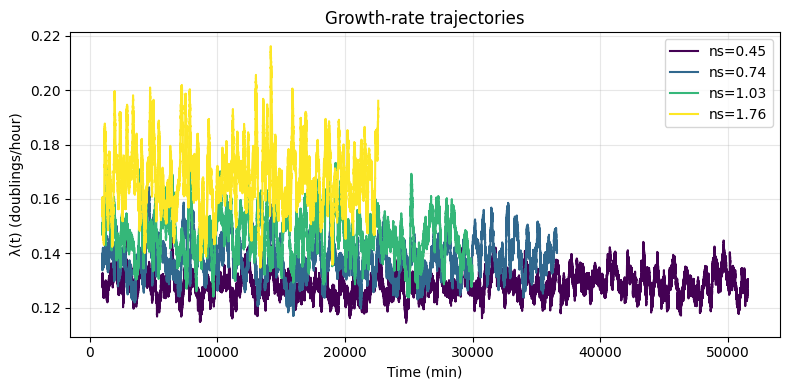

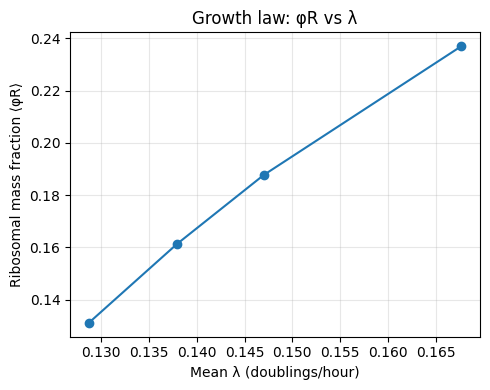

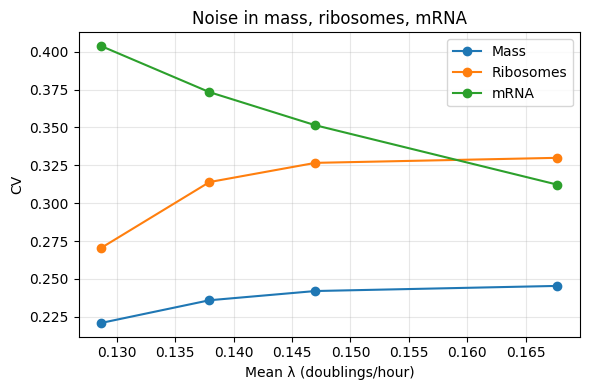

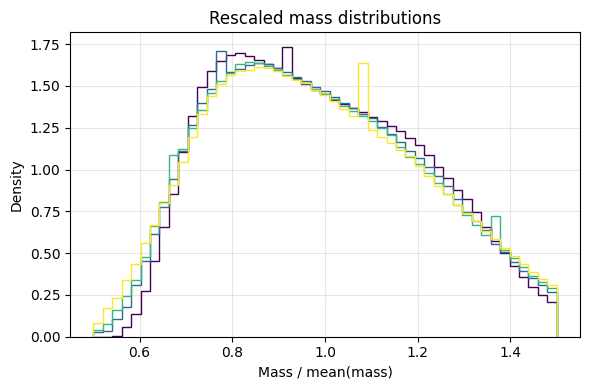

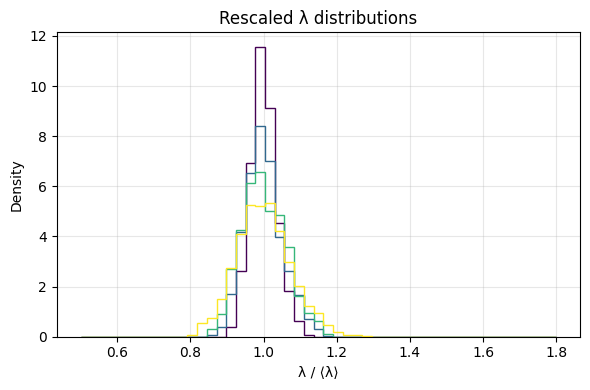

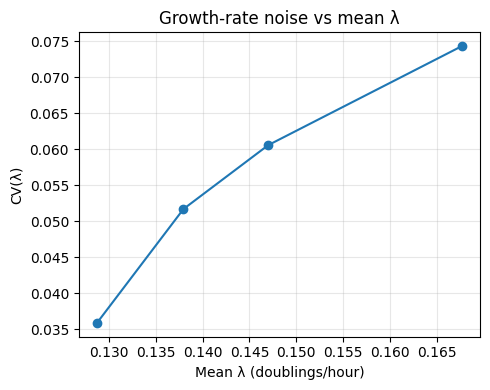

In [16]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# ============================================================
# FILES AND CONSTANTS
# ============================================================
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

NR = 7549.0
NX = 300.0
GMAX = 1260.0
KGAMMA = 7.0

BURN_IN = 1000.0
MIN_TO_DLB = 60.0 / np.log(2.0)

# ============================================================
# HELPERS
# ============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    nonribo_mass = NX * (q + et + em)
    return ribo_mass + nonribo_mass, ribo_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA * mass / 1e8 + a)
    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )
    return active * gamma

# ============================================================
# STORAGE
# ============================================================
ns_values = []
lambda_mean_all = []
phiR_mean_all = []

cv_mass_all = []
cv_ribo_all = []
cv_mrna_all = []
cv_lambda_all = []

lam_rescaled_all = []
mass_rescaled_all = []

t_ss_all = []
lam_ss_all = []

# ============================================================
# MAIN LOOP
# ============================================================
for ns, filename in FILES.items():
    df = load_arrow(filename)
    t = df["timestamp"].to_numpy()

    mass, ribo_mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)

    lam = ttrate / mass
    lam_dlb = lam * MIN_TO_DLB

    phiR = ribo_mass / mass
    mrna = (df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]).to_numpy()

    N = min(len(t), len(mass), len(lam_dlb))
    t = t[:N]
    lam_dlb = lam_dlb[:N]
    mass = mass[:N]
    ribo_mass = ribo_mass[:N]
    phiR = phiR[:N]
    mrna = mrna[:N]

    mask = t >= BURN_IN
    t_ss = t[mask]
    lam_ss = lam_dlb[mask]
    mass_ss = mass[mask]
    ribo_ss = ribo_mass[mask]
    mrna_ss = mrna[mask]
    phiR_ss = phiR[mask]

    valid = (~np.isnan(lam_ss)) & (~np.isnan(mass_ss))
    t_ss = t_ss[valid]
    lam_ss = lam_ss[valid]
    mass_ss = mass_ss[valid]
    ribo_ss = ribo_ss[valid]
    mrna_ss = mrna_ss[valid]
    phiR_ss = phiR_ss[valid]

    ns_values.append(ns)

    t_ss_all.append(t_ss)
    lam_ss_all.append(lam_ss)

    lambda_mean_all.append(np.mean(lam_ss))
    phiR_mean_all.append(np.mean(phiR_ss))

    cv_mass_all.append(np.std(mass_ss)/np.mean(mass_ss))
    cv_ribo_all.append(np.std(ribo_ss)/np.mean(ribo_ss))
    cv_mrna_all.append(np.std(mrna_ss)/np.mean(mrna_ss))
    cv_lambda_all.append(np.std(lam_ss)/np.mean(lam_ss))

    mass_rescaled_all.append(mass_ss / np.mean(mass_ss))
    lam_rescaled_all.append(lam_ss / np.mean(lam_ss))

# ============================================================
# COLOURS
# ============================================================
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_values)))

# ============================================================
# FIGURE 1 — Growth rate time series
# ============================================================
plt.figure(figsize=(8,4))
for ns, t_ss, lam, col in zip(ns_values, t_ss_all, lam_ss_all, COLORS):
    plt.plot(t_ss, lam, color=col, label=f"ns={ns}")
plt.xlabel("Time (min)")
plt.ylabel("λ(t) (doublings/hour)")
plt.title("Growth-rate trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2a — ⟨phiR⟩ vs ⟨lambda⟩
# ============================================================
plt.figure(figsize=(5,4))
plt.plot(lambda_mean_all, phiR_mean_all, "o-")
plt.xlabel("Mean λ (doublings/hour)")
plt.ylabel("Ribosomal mass fraction ⟨φR⟩")
plt.title("Growth law: φR vs λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2b — CV of mass, ribosomes, mRNA
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(lambda_mean_all, cv_mass_all, "o-", label="Mass")
plt.plot(lambda_mean_all, cv_ribo_all, "o-", label="Ribosomes")
plt.plot(lambda_mean_all, cv_mrna_all, "o-", label="mRNA")
plt.xlabel("Mean λ (doublings/hour)")
plt.ylabel("CV")
plt.title("Noise in mass, ribosomes, mRNA")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2c — Rescaled mass distributions
# ============================================================
plt.figure(figsize=(6,4))
bins = np.linspace(0.5,1.5,50)
for rescaled, col in zip(mass_rescaled_all, COLORS):
    plt.hist(rescaled, bins=bins, histtype="step", density=True, color=col)
plt.xlabel("Mass / mean(mass)")
plt.ylabel("Density")
plt.title("Rescaled mass distributions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2d — Rescaled λ distributions
# ============================================================
plt.figure(figsize=(6,4))
bins = np.linspace(0.5,1.8,50)
for rescaled, col in zip(lam_rescaled_all, COLORS):
    plt.hist(rescaled, bins=bins, histtype="step", density=True, color=col)
plt.xlabel("λ / ⟨λ⟩")
plt.ylabel("Density")
plt.title("Rescaled λ distributions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2e — Growth-rate CV
# ============================================================
plt.figure(figsize=(5,4))
plt.plot(lambda_mean_all, cv_lambda_all, "o-", color="tab:blue")
plt.xlabel("Mean λ (doublings/hour)")
plt.ylabel("CV(λ)")
plt.title("Growth-rate noise vs mean λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


     ns  mean_lam     mean_mass     mean_ribo  mean_mrna  mean_phiR   cv_mass  \
0  0.45  0.016159  1.085650e+09  18973.310829  14.167292   0.131129  0.220943   
1  0.74  0.020624  1.289342e+09  27883.530664  18.230535   0.161359  0.235889   
2  1.03  0.025004  1.463879e+09  36909.824734  20.881715   0.187720  0.241978   
3  1.76  0.036321  1.859150e+09  59254.227508  26.090197   0.237060  0.245353   

    cv_ribo   cv_mrna    cv_lam  
0  0.270556  0.403623  0.228893  
1  0.313909  0.373276  0.258496  
2  0.326589  0.351417  0.273658  
3  0.329909  0.312219  0.289869  


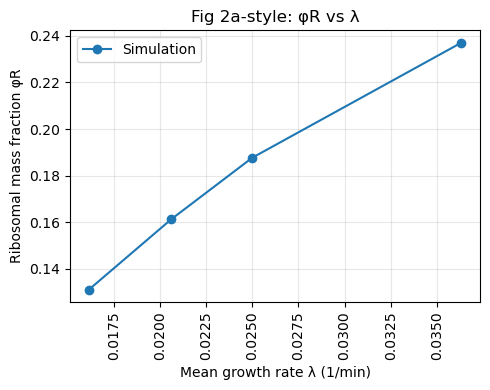

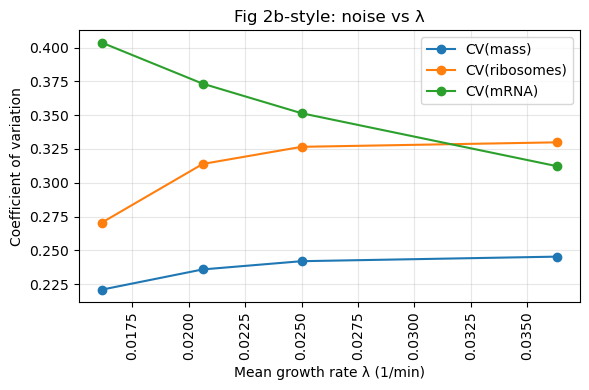

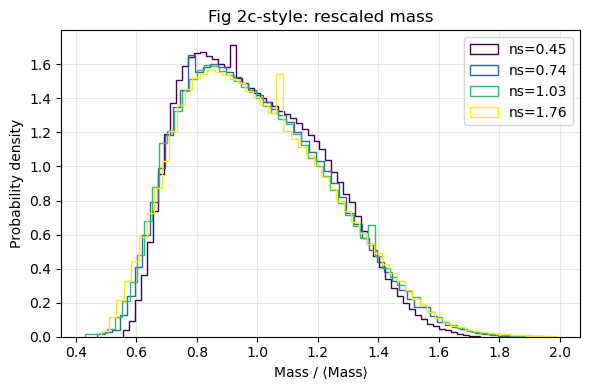

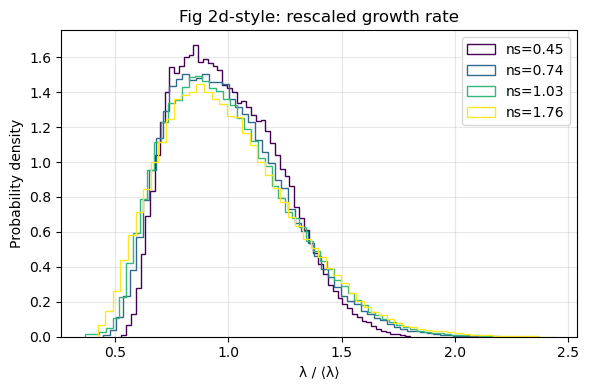

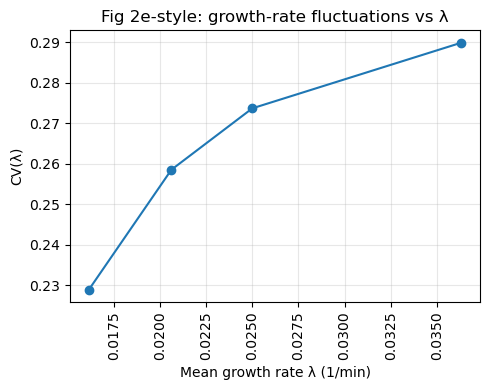

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# ===============================================================
#  FILES AND CONSTANTS
# ===============================================================
FILES_WITH_NS = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

# Parameters from your model (no extra SF, SF = 1)
NR = 7549.0     # ribosome mass factor
NX = 300.0      # non-ribosomal protein mass factor (q, et, em)
GMAX = 1260.0
KGAMMA = 7.0
MREF = 1e8      # used in lam = ttrate / Mref
BURN_IN_TIME = 1000.0  # minutes; adjust if needed


def load_arrow(path: str) -> pd.DataFrame:
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df: pd.DataFrame) -> np.ndarray:
    """
    mass(nr, r, rmm, rmt, rmq, rmr, zmm, zmt, zmq, zmr, nx, q, et, em)
      = nr * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
        + nx * (q + et + em)
    """
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_block = r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr
    prot_block = q + et + em

    mass = NR * ribo_block + NX * prot_block
    return mass

def compute_lambda(df: pd.DataFrame) -> np.ndarray:
    """
    λ(t) = ttrate / Mref, ttrate = (rmr+rmt+rmm+rmq) * gamma(a),
    gamma(a) = gmax * a / (Kgamma + a).
    Units: 1/min (no conversion to doublings/hour).
    """
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA + a)

    active = (
        df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()

    ttrate = active * gamma
    lam = ttrate / MREF  # 1/min
    return lam

def total_ribosomes(df: pd.DataFrame) -> np.ndarray:
    return (
        df["r(t)"] + df["rmr(t)"] + df["rmt(t)"] +
        df["rmm(t)"] + df["rmq(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

def total_mrna(df: pd.DataFrame) -> np.ndarray:
    return (df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]).to_numpy()

def coeff_var(x: np.ndarray) -> float:
    x = np.asarray(x)
    m = x.mean()
    if m == 0:
        return np.nan
    return x.std(ddof=1) / m


summary = []
traj = {}

for fname, ns in FILES_WITH_NS:
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    lam = compute_lambda(df)       # 1/min
    mass = compute_mass(df)
    ribo = total_ribosomes(df)
    mrna = total_mrna(df)

    # ribosomal mass fraction φR = (ribosomal mass) / total mass
    ribo_mass = NR * ribo
    phiR_t = ribo_mass / mass

    # burn-in
    mask = t >= BURN_IN_TIME
    t_ss     = t[mask]
    lam_ss   = lam[mask]
    mass_ss  = mass[mask]
    ribo_ss  = ribo[mask]
    mrna_ss  = mrna[mask]
    phiR_ss  = phiR_t[mask]

    mean_lam   = lam_ss.mean()
    mean_mass  = mass_ss.mean()
    mean_ribo  = ribo_ss.mean()
    mean_mrna  = mrna_ss.mean()
    mean_phiR  = phiR_ss.mean()

    cv_mass  = coeff_var(mass_ss)
    cv_ribo  = coeff_var(ribo_ss)
    cv_mrna  = coeff_var(mrna_ss)
    cv_lam   = coeff_var(lam_ss)

    summary.append(dict(
        ns=ns,
        mean_lam=mean_lam,
        mean_mass=mean_mass,
        mean_ribo=mean_ribo,
        mean_mrna=mean_mrna,
        mean_phiR=mean_phiR,
        cv_mass=cv_mass,
        cv_ribo=cv_ribo,
        cv_mrna=cv_mrna,
        cv_lam=cv_lam
    ))

    traj[ns] = dict(
        t=t_ss,
        lam=lam_ss,
        mass=mass_ss,
        ribo=ribo_ss,
        mrna=mrna_ss,
        phiR=phiR_ss
    )

summary_df = pd.DataFrame(summary).sort_values("ns")
print(summary_df)

mean_lam   = summary_df["mean_lam"].to_numpy()
mean_phiR  = summary_df["mean_phiR"].to_numpy()
cv_mass    = summary_df["cv_mass"].to_numpy()
cv_ribo    = summary_df["cv_ribo"].to_numpy()
cv_mrna    = summary_df["cv_mrna"].to_numpy()
cv_lam     = summary_df["cv_lam"].to_numpy()

# ===============================================================
#  Fig 2a-style: φR vs mean λ
# ===============================================================
plt.figure(figsize=(5,4))
plt.plot(mean_lam, mean_phiR, "o-", label="Simulation")
plt.xticks(rotation=90)
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Ribosomal mass fraction φR")
plt.title("Fig 2a-style: φR vs λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
#  Fig 2b-style: CV(mass), CV(ribo), CV(mRNA) vs λ
# ===============================================================
plt.figure(figsize=(6,4))
plt.plot(mean_lam, cv_mass, "o-", label="CV(mass)")
plt.plot(mean_lam, cv_ribo, "o-", label="CV(ribosomes)")
plt.plot(mean_lam, cv_mrna, "o-", label="CV(mRNA)")
plt.xlabel("Mean growth rate λ (1/min)")
plt.xticks(rotation=90)
plt.ylabel("Coefficient of variation")
plt.title("Fig 2b-style: noise vs λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
#  Fig 2c/d-style: rescaled mass and λ distributions
# ===============================================================
colors = plt.cm.viridis(np.linspace(0, 1, len(FILES_WITH_NS)))

# Rescaled mass
plt.figure(figsize=(6,4))
for (fname, ns), col in zip(FILES_WITH_NS, colors):
    m = traj[ns]["mass"]
    m_rescaled = m / m.mean()
    plt.hist(m_rescaled, bins=60, density=True,
             histtype="step", color=col, label=f"ns={ns:.2f}")
plt.xlabel("Mass / ⟨Mass⟩")
plt.ylabel("Probability density")
plt.title("Fig 2c-style: rescaled mass")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Rescaled λ
plt.figure(figsize=(6,4))
for (fname, ns), col in zip(FILES_WITH_NS, colors):
    lam_vals = traj[ns]["lam"]
    lam_rescaled = lam_vals / lam_vals.mean()
    plt.hist(lam_rescaled, bins=60, density=True,
             histtype="step", color=col, label=f"ns={ns:.2f}")
plt.xlabel("λ / ⟨λ⟩")
plt.ylabel("Probability density")
plt.title("Fig 2d-style: rescaled growth rate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
#  Fig 2e-style: CV(λ) vs mean λ
# ===============================================================
plt.figure(figsize=(5,4))
plt.plot(mean_lam, cv_lam, "o-", color="tab:blue")
plt.xlabel("Mean growth rate λ (1/min)")
plt.xticks(rotation=90)
plt.ylabel("CV(λ)")
plt.title("Fig 2e-style: growth-rate fluctuations vs λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


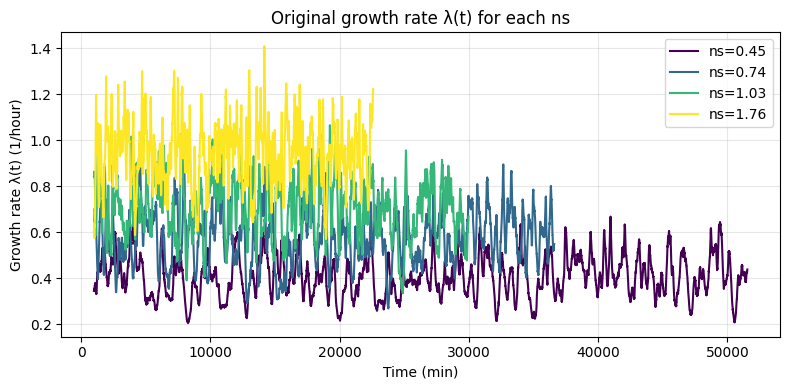

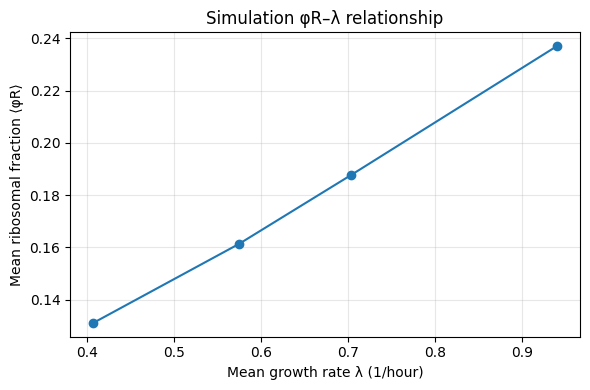

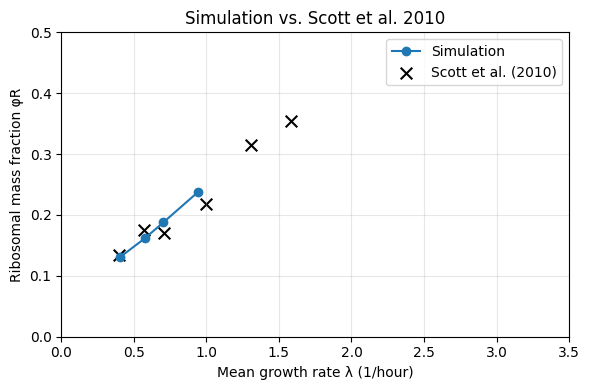

In [67]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# ===============================================================
# Files and constants
# ===============================================================
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

NR = 7549.0      # ribosomal protein size
NX = 300.0       # non-ribosomal protein size
GMAX = 12600.0
KGAMMA = 7*22000*1

BURN_IN = 1000.0          # minutes
MIN_TO_DLB = 60.0 / np.log(2.0)   # 1/min → doubling/hour

# ===============================================================
# Helpers
# ===============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo_mass

    return ribo_mass, non_ribo_mass, total_mass

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )

    return active * gamma

def smooth(y, w=800):
    kernel = np.ones(w) / w
    return np.convolve(y, kernel, mode="same")

def downsample(t, y, step=20):
    return t[::step], y[::step]

# ===============================================================
# STORAGE FOR RESULTS
# ===============================================================
ns_values = []
t_ss_all = []
lam_ss_all = []
phiR_mean_all = []
lambda_mean_all = []

# ===============================================================
# MAIN LOOP
# ===============================================================
for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()


    # mass and translation flux
    ribo_mass, non_ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)

    # growth rate 1/min → dbl/hour
    lam = ((ttrate) / mass_full) * 60 #MIN_TO_DLB
    #lam = np.diff(np.log(mass_full)) / np.diff(t)

    # ribosomal fraction
    phiR = ribo_mass / mass_full # Is mass_full equivalent to cellular protein mass or should it be non_ribo_mass?
    #phiR = ribo_mass / non_ribo_mass 

    # align lengths
    N = min(len(t), len(lam), len(phiR))
    t = t[:N]
    lam = lam[:N]
    phiR = phiR[:N]

    # burn-in
    mask = t >= BURN_IN
    t_ss = t[mask]
    lam_ss = lam[mask]
    phiR_ss = phiR[mask]

    # remove NaNs
    valid = (~np.isnan(t_ss)) & (~np.isnan(lam_ss)) & (~np.isnan(phiR_ss))
    t_ss = t_ss[valid]
    lam_ss = lam_ss[valid]
    phiR_ss = phiR_ss[valid]

    # store
    ns_values.append(ns)
    t_ss_all.append(t_ss)
    lam_ss_all.append(lam_ss)
    phiR_mean_all.append(np.mean(phiR_ss))
    lambda_mean_all.append(np.mean(lam_ss))

# ===============================================================
# PLOT 1 — λ(t) vs time (smoothed, downsampled)
# ===============================================================
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_values)))

plt.figure(figsize=(8,4))

for ns, t_ss, lam, col in zip(ns_values, t_ss_all, lam_ss_all, COLORS):
    lam_smooth = lam
    t_ds, lam_ds = downsample(t_ss, lam_smooth, step=20)
    plt.plot(t_ds, lam_ds, color=col, label=f"ns={ns}")

plt.xlabel("Time (min)")
plt.ylabel("Growth rate λ(t) (1/hour)")
plt.title("Original growth rate λ(t) for each ns")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
# PLOT 2 — Growth-law φR vs λ (simulation summary)
# ===============================================================
plt.figure(figsize=(6,4))
plt.plot(lambda_mean_all, phiR_mean_all, "o-", color="tab:blue")
plt.xlabel("Mean growth rate λ (1/hour)")
plt.ylabel("Mean ribosomal fraction ⟨φR⟩")
plt.title("Simulation φR–λ relationship")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===============================================================
# PLOT 3 — Overlay with Scott et al. 2010
# ===============================================================
# Load experimental Scott data
scott = pd.read_csv("Scott_Data.csv")
scott0 = scott[scott["cl"] == 0]
phiR_scott = scott0["fr"].values
lambda_scott = scott0["lambda"].values * 60.0  #* NR   # convert 1/h → 1/min


plt.figure(figsize=(6,4))
plt.plot(lambda_mean_all, phiR_mean_all, "o-", label="Simulation", color="tab:blue")

plt.scatter(lambda_scott, phiR_scott, color="black",
            s=70, marker="x", label="Scott et al. (2010)")

plt.xlabel("Mean growth rate λ (1/hour)")
plt.ylabel("Ribosomal mass fraction φR")
plt.ylim(0, 0.5)
plt.xlim(0, 3.5)
plt.title("Simulation vs. Scott et al. 2010")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


ns: 0.45
mean growth rate 0.4072432927115618
ns: 0.74
mean growth rate 0.5745281541637585
ns: 1.03
mean growth rate 0.7032015724576248
ns: 1.76
mean growth rate 0.939532075251043


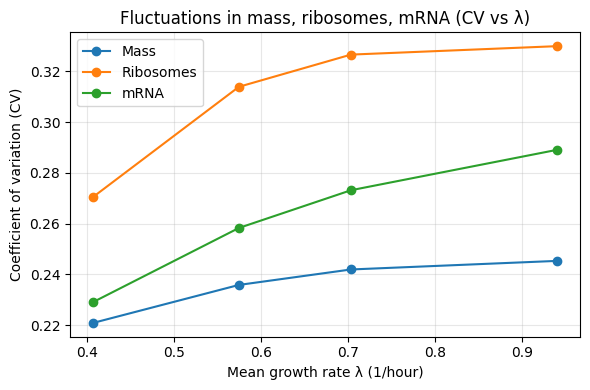

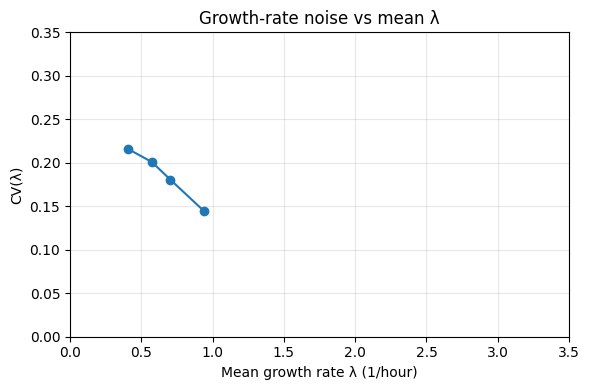

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import variation

# ===============================================================
# CV STORAGE
# ===============================================================
mean_lambda = []
cv_mass     = []
cv_ribo     = []
cv_mrna     = []
cv_lambda   = []

for ns, fname in FILES.items():

    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    ribo_mass, non_ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)

    # λ(t) in 1/hour
    lam = (ttrate / mass_full) * 60  

    # ribosome counts (free + active)
    ribo_counts = (
        df["r(t)"].to_numpy() +
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    # total mRNA
    mrna_counts = (
    df["mm(t)"].to_numpy() +
    df["mt(t)"].to_numpy() +
    df["mq(t)"].to_numpy() +
    df["mr(t)"].to_numpy() +
    df["rmm(t)"].to_numpy() +
    df["rmt(t)"].to_numpy() +
    df["rmq(t)"].to_numpy() +
    df["rmr(t)"].to_numpy() +
    df["zmm(t)"].to_numpy() +
    df["zmt(t)"].to_numpy() +
    df["zmq(t)"].to_numpy() +
    df["zmr(t)"].to_numpy()
)


    # burn-in
    mask = t >= BURN_IN
    lam_ss   = lam[mask]
    mass_ss  = mass_full[mask]
    ribo_ss  = ribo_counts[mask]
    mrna_ss  = mrna_counts[mask]

    # drop NaNs
    valid = (
        ~np.isnan(lam_ss) &
        ~np.isnan(mass_ss) &
        ~np.isnan(ribo_ss) &
        ~np.isnan(mrna_ss)
    )

    lam_ss   = lam_ss[valid]
    mass_ss  = mass_ss[valid]
    ribo_ss  = ribo_ss[valid]
    mrna_ss  = mrna_ss[valid]

    # store means and CVs
    mean_lambda.append(np.mean(lam_ss))
    print("ns:", ns) 
    print("mean growth rate", np.mean(lam_ss))
    cv_mass.append(np.std(mass_ss)  / np.mean(mass_ss))
    cv_ribo.append(np.std(ribo_ss)  / np.mean(ribo_ss))
    cv_mrna.append(np.std(mrna_ss)  / np.mean(mrna_ss))
    cv_lambda.append(np.std(lam_ss) / np.mean(lam_ss))

# ===============================================================
# PLOT — CVs of mass/ribosomes/mRNA vs mean λ (Fig. 2b style)
# ===============================================================
plt.figure(figsize=(6,4))
plt.plot(mean_lambda, cv_mass, "o-", label="Mass")
plt.plot(mean_lambda, cv_ribo, "o-", label="Ribosomes")
plt.plot(mean_lambda, cv_mrna, "o-", label="mRNA")

plt.xlabel("Mean growth rate λ (1/hour)")
plt.ylabel("Coefficient of variation (CV)")
plt.title("Fluctuations in mass, ribosomes, mRNA (CV vs λ)")
plt.grid(alpha=0.3)
# plt.xlim(0,3)
# plt.ylim(0,0.45)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
# PLOT — Growth-rate fluctuations vs mean λ (Fig. 2e style)
# ===============================================================
plt.figure(figsize=(6,4))
plt.plot(mean_lambda, cv_lambda, "o-", color="tab:blue")

plt.xlabel("Mean growth rate λ (1/hour)")
plt.ylabel("CV(λ)")
plt.title("Growth-rate noise vs mean λ")
plt.xlim(0,3.5)
plt.ylim(0,0.35)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


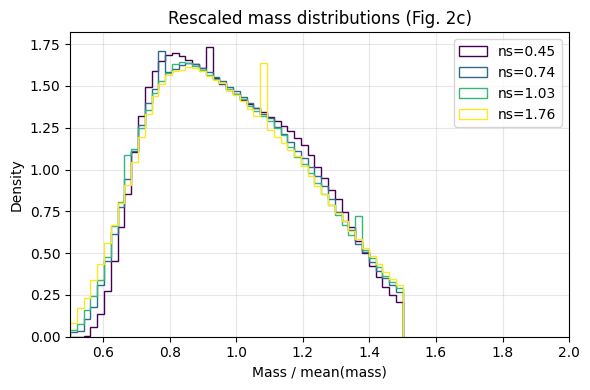

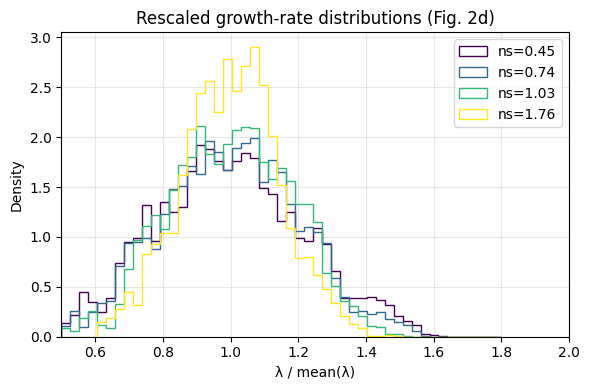

In [84]:
# ===============================================================
# FIG 2c–d RESCALED DISTRIBUTIONS
# ===============================================================

mass_rescaled_all = []
lam_rescaled_all  = []
ns_values_ordered = []

for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    # ---- Compute mass and lambda ----
    ribo_mass, non_ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)
    lam = (ttrate / mass_full) * 60.0   # 1/hour

    # ---- Burn-in ----
    mask = t >= BURN_IN
    mass_ss = mass_full[mask]
    lam_ss  = lam[mask]

    # ---- Drop NaN ----
    good = (~np.isnan(mass_ss)) & (~np.isnan(lam_ss))
    mass_ss = mass_ss[good]
    lam_ss  = lam_ss[good]

    # ---- Rescale ----
    mass_rescaled = mass_ss / np.mean(mass_ss)
    lam_rescaled  = lam_ss  / np.mean(lam_ss)

    mass_rescaled_all.append(mass_rescaled)
    lam_rescaled_all.append(lam_rescaled)
    ns_values_ordered.append(ns)

# Colors
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_values_ordered)))


# ===============================================================
# FIG 2c — Rescaled Mass Distributions
# ===============================================================
plt.figure(figsize=(6,4))
bins_mass = np.linspace(0.5, 1.5, 50)

for rescaled, col, ns in zip(mass_rescaled_all, COLORS, ns_values_ordered):
    plt.hist(rescaled, bins=bins_mass, histtype="step",
             density=True, color=col, label=f"ns={ns}")

plt.xlabel("Mass / mean(mass)")
plt.ylabel("Density")
plt.title("Rescaled mass distributions (Fig. 2c)")
plt.xlim(0.5, 2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ===============================================================
# FIG 2d — Rescaled Growth Rate Distributions
# ===============================================================
plt.figure(figsize=(6,4))
bins_lam = np.linspace(0.5, 1.8, 50)

for rescaled, col, ns in zip(lam_rescaled_all, COLORS, ns_values_ordered):
    plt.hist(rescaled, bins=bins_lam, histtype="step",
             density=True, color=col, label=f"ns={ns}")

plt.xlabel("λ / mean(λ)")
plt.ylabel("Density")
plt.title("Rescaled growth-rate distributions (Fig. 2d)")
plt.xlim(0.5, 2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


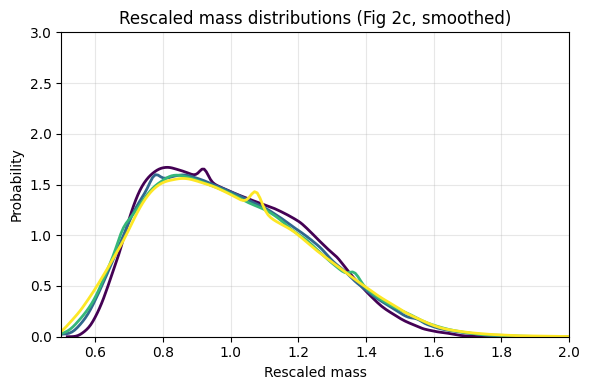

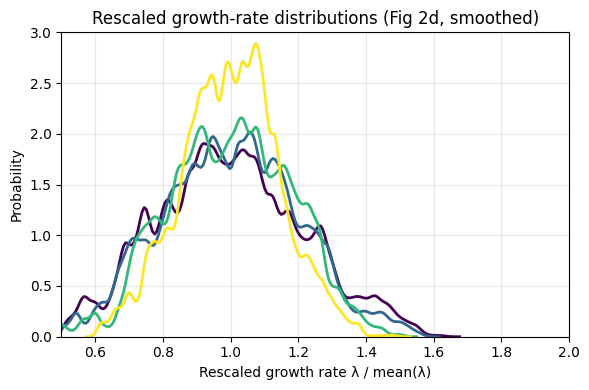

In [89]:
# ===============================================================
# FIG 2c–d RESCALED DISTRIBUTIONS
# ===============================================================

mass_rescaled_all = []
lam_rescaled_all  = []
ns_values_ordered = []

for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    # ---- Compute mass and lambda ----
    ribo_mass, non_ribo_mass, mass_full = compute_mass(df)
    ttrate = compute_ttrate(df, mass_full)
    lam = (ttrate / mass_full) * 60.0   # 1/hour

    # ---- Burn-in ----
    mask = t >= BURN_IN
    mass_ss = mass_full[mask]
    lam_ss  = lam[mask]

    # ---- Drop NaN ----
    good = (~np.isnan(mass_ss)) & (~np.isnan(lam_ss))
    mass_ss = mass_ss[good]
    lam_ss  = lam_ss[good]

    # ---- Rescale ----
    mass_rescaled = mass_ss / np.mean(mass_ss)
    lam_rescaled  = lam_ss  / np.mean(lam_ss)

    mass_rescaled_all.append(mass_rescaled)
    lam_rescaled_all.append(lam_rescaled)
    ns_values_ordered.append(ns)

# Colors
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_values_ordered)))


# ===============================================================
# FIG 2c — Rescaled Mass Distributions
# ===============================================================
# FIG 2c — Rescaled Mass Distributions (paper-style "Probability")
import seaborn as sns

plt.figure(figsize=(6,4))

for rescaled, col, ns in zip(mass_rescaled_all, COLORS, ns_values):
    sns.kdeplot(
        rescaled,
        bw_adjust=0.7,    # smoothness (0.5–1.0 works well)
        color=col,
        linewidth=2,
        label=f"ns={ns}"
    )

plt.xlabel("Rescaled mass")
plt.ylabel("Probability")
plt.xlim(0.5, 2.0)
plt.ylim(0,3)
plt.ylim(0, None)
plt.title("Rescaled mass distributions (Fig 2c, smoothed)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()





# ===============================================================
# FIG 2d — Rescaled Growth Rate Distributions
# ===============================================================
# FIG 2d — Rescaled Growth-Rate Distributions (paper-style "Probability")
plt.figure(figsize=(6,4))

for rescaled, col, ns in zip(lam_rescaled_all, COLORS, ns_values):
    sns.kdeplot(
        rescaled,
        bw_adjust=0.7,
        color=col,
        linewidth=2,
        label=f"ns={ns}"
    )

plt.xlabel("Rescaled growth rate λ / mean(λ)")
plt.ylabel("Probability")
plt.xlim(0.5, 2.0)
plt.ylim(0, 3)
plt.title("Rescaled growth-rate distributions (Fig 2d, smoothed)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




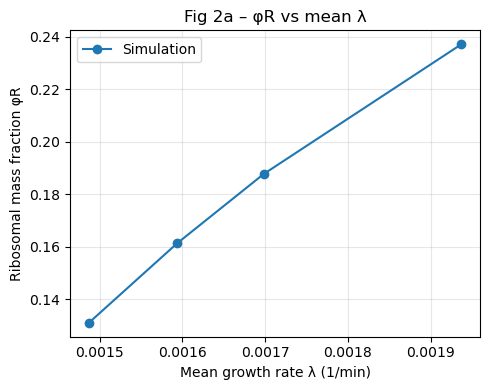

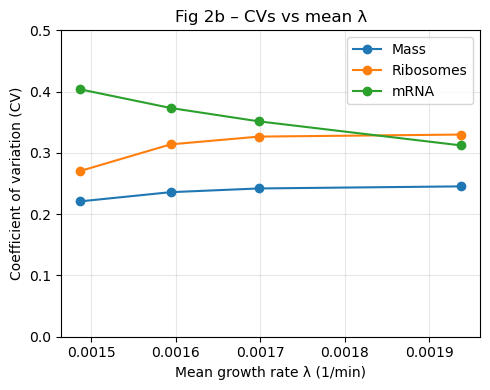

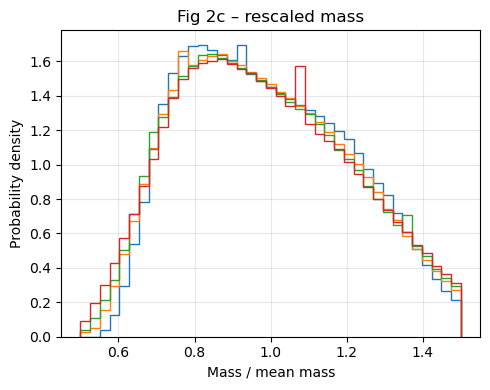

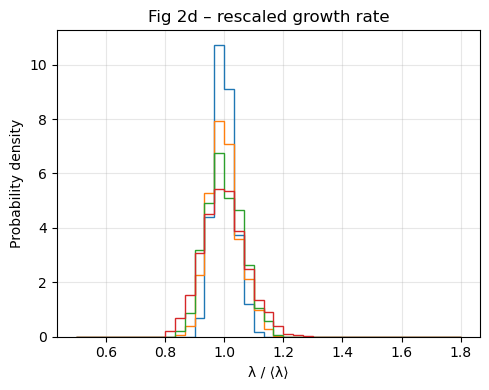

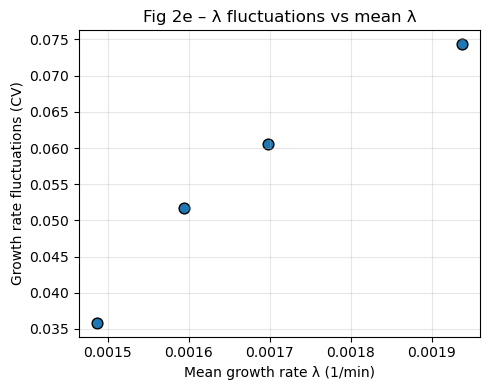

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# -------------------------------------------------------
# Files and constants
# -------------------------------------------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

# Parameters from your model
NR = 7549.0     # ribosomal protein "size"
NX = 300.0      # average non-ribosomal protein "size"
GMAX = 1260.0
KGAMMA = 7.0

BURN_IN_TIME = 1000.0   # minutes; adjust if you like

# -------------------------------------------------------
# Utilities
# -------------------------------------------------------
def load_arrow(path):
    """Read pyarrow file into DataFrame."""
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_and_phiR(df):
    """
    Total mass M(t) and ribosomal mass fraction φR(t),
    using the same formula as in the Julia mass(...) function:

    mass = nr * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
           + nx * (q + et + em)
    """
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass     = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    mass = ribo_mass + non_ribo_mass

    phiR = ribo_mass / mass
    return mass, phiR

def compute_lambda(df):
    """
    Growth rate λ(t) = translation flux / actual mass M(t).

    translation flux = gamma(a) * (# active ribosomes)
    where gamma(a) = GMAX * a / (KGAMMA + a)
    and "active" = rmr + rmt + rmm + rmq


    Calculate mass here so that it is calculated again at each time point
    gamma = GMAX*a/((KGAMMA*v1)/1e8 +a)
    """
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA + a)

    active = (
        df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()
    mass = compute_mass_and_phiR(df)

    ttrate = active * gamma
    lam = ttrate / mass
    return lam

def total_mrna(df):
    """Total mRNA (free): mm + mt + mq + mr."""
    return (
        df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]
    ).to_numpy()

# -------------------------------------------------------
# Collect statistics across ns
# -------------------------------------------------------
mean_lambda = []
mean_phiR   = []

cv_mass = []
cv_ribo = []
cv_mrna = []

rescaled_mass_all   = []
rescaled_lambda_all = []

mean_lambda_for_cv = []
growth_rate_cv      = []

for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    # mass and ribosomal fraction
    mass, phiR = compute_mass_and_phiR(df)

    # growth rate using *actual* mass
    lam = compute_lambda(df, mass)

    # total ribosomes (free + active) and mRNA
    ribo_tot = (
        df["r(t)"] + df["rmr(t)"] + df["rmt(t)"] +
        df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()
    mrna = total_mrna(df)

    # burn-in mask
    mask = t >= BURN_IN_TIME

    lam_ss   = lam[mask]
    mass_ss  = mass[mask]
    phiR_ss  = phiR[mask]
    ribo_ss  = ribo_tot[mask]
    mrna_ss  = mrna[mask]

    # ---- Fig 2a: φR vs mean λ ----
    mean_lambda.append(np.mean(lam_ss))
    mean_phiR.append(np.mean(phiR_ss))

    # ---- Fig 2b: CVs ----
    cv_mass.append(variation(mass_ss))
    cv_ribo.append(variation(ribo_ss))
    cv_mrna.append(variation(mrna_ss))

    # ---- Fig 2c: rescaled mass ----
    rescaled_mass_all.append(mass_ss / np.mean(mass_ss))

    # ---- Fig 2d: rescaled λ ----
    rescaled_lambda_all.append(lam_ss / np.mean(lam_ss))

    # ---- Fig 2e: CV of λ ----
    mean_lambda_for_cv.append(np.mean(lam_ss))
    growth_rate_cv.append(variation(lam_ss))

# -------------------------------------------------------
# Plot Fig 2a–e style panels
# -------------------------------------------------------

# (a) ribosomal fraction vs mean λ
plt.figure(figsize=(5,4))
plt.plot(mean_lambda, mean_phiR, "o-", label="Simulation")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Ribosomal mass fraction φR")
plt.title("Fig 2a – φR vs mean λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# (b) CVs of mass, ribosomes, mRNA vs λ
plt.figure(figsize=(5,4))
plt.ylim(0, 0.5)
plt.plot(mean_lambda, cv_mass, "o-", label="Mass")
plt.plot(mean_lambda, cv_ribo, "o-", label="Ribosomes")
plt.plot(mean_lambda, cv_mrna, "o-", label="mRNA")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Coefficient of variation (CV)")
plt.title("Fig 2b – CVs vs mean λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# (c) rescaled mass distributions
plt.figure(figsize=(5,4))
bins_mass = np.linspace(0.5, 1.5, 40)
for rescaled in rescaled_mass_all:
    plt.hist(rescaled, bins=bins_mass, histtype="step", density=True)
plt.xlabel("Mass / mean mass")
plt.ylabel("Probability density")
plt.title("Fig 2c – rescaled mass")
plt.grid(alpha=0.3)
plt.tight_layout()

# (d) rescaled growth rate distributions
plt.figure(figsize=(5,4))
bins_lam = np.linspace(0.5, 1.8, 40)
for rescaled in rescaled_lambda_all:
    plt.hist(rescaled, bins=bins_lam, histtype="step", density=True)
plt.xlabel("λ / ⟨λ⟩")
plt.ylabel("Probability density")
plt.title("Fig 2d – rescaled growth rate")
plt.grid(alpha=0.3)
plt.tight_layout()

# (e) CV of λ vs mean λ
plt.figure(figsize=(5,4))
plt.scatter(mean_lambda_for_cv, growth_rate_cv, s=60, edgecolor="k")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Growth rate fluctuations (CV)")
plt.title("Fig 2e – λ fluctuations vs mean λ")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


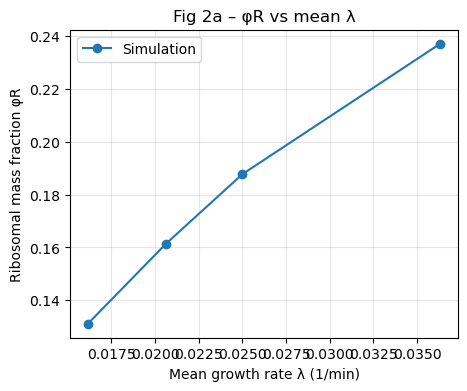

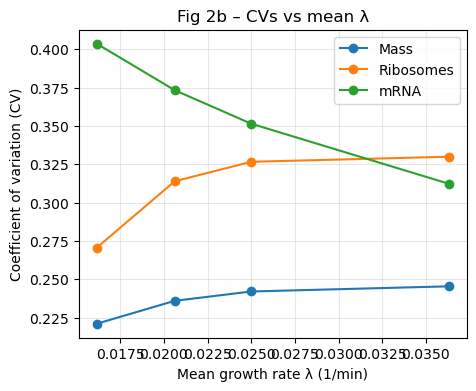

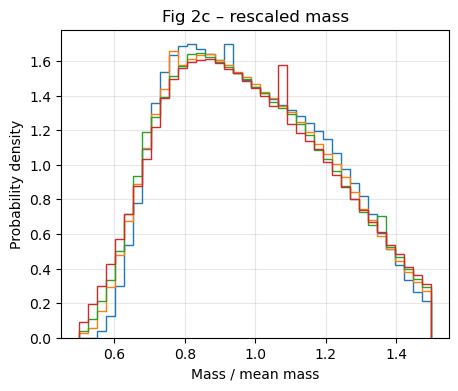

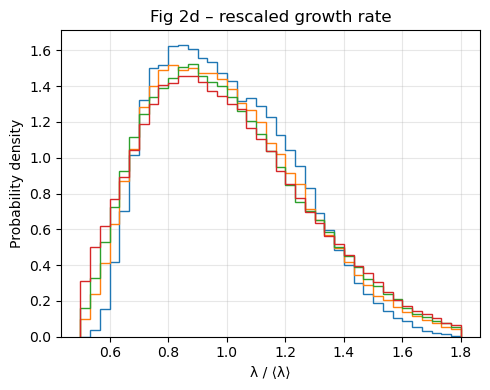

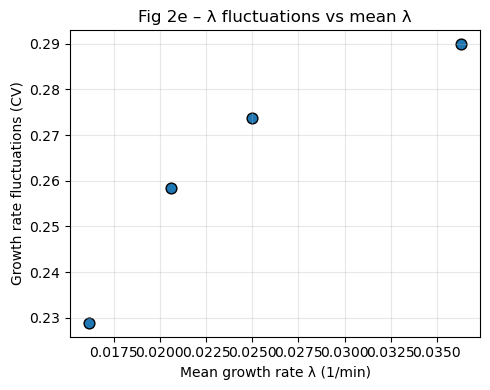

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# -------------------------------------------------------
# Files and constants
# -------------------------------------------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

# Parameters from your model
NR = 7549.0     # ribosomal protein size
NX = 300.0      # average non-ribosomal protein size
GMAX = 1260.0
KGAMMA = 7.0
MREF = 1e8      # used in lam(gamma)/Mref in the stochastic model

BURN_IN_TIME = 1000.0   # minutes; adjust if you like

# -------------------------------------------------------
# Utilities
# -------------------------------------------------------
def load_arrow(path):
    """Read pyarrow file into DataFrame."""
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_lambda(df):
    """Growth rate λ(t) = translation flux / Mref.
    gamma needs to use v1 to scale properly, use np.divide for ttrate to divide lists ttrate/mass
    """
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA + a)

    active = (
        df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()

    ttrate = active * gamma
    lam = ttrate / Mref
    return lam

def compute_mass_and_phiR(df):
    """
    Total mass M(t) and ribosomal mass fraction φR(t),
    using the same formula as in the Julia mass(...) function.
    """
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)
    mass = ribo_mass + non_ribo_mass

    phiR = ribo_mass / mass
    return mass, phiR

def total_mrna(df):
    return (df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]).to_numpy()

# -------------------------------------------------------
# Collect statistics across ns
# -------------------------------------------------------
mean_lambda = []
mean_phiR   = []

cv_mass = []
cv_ribo = []
cv_mrna = []

rescaled_mass_all   = []
rescaled_lambda_all = []

mean_lambda_for_cv = []
growth_rate_cv      = []

for ns, fname in FILES.items():
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    lam = compute_lambda(df)
    mass, phiR = compute_mass_and_phiR(df)
    ribo_tot = (df["r(t)"] + df["rmr(t)"] + df["rmt(t)"] +
                df["rmm(t)"] + df["rmq(t)"]).to_numpy()
    mrna = total_mrna(df)

    # burn-in mask
    mask = t >= BURN_IN_TIME

    lam_ss   = lam[mask]
    mass_ss  = mass[mask]
    phiR_ss  = phiR[mask]
    ribo_ss  = ribo_tot[mask]
    mrna_ss  = mrna[mask]

    # ---- Fig 2a: φR vs mean λ ----
    mean_lambda.append(np.mean(lam_ss))
    mean_phiR.append(np.mean(phiR_ss))

    # ---- Fig 2b: CVs ----
    cv_mass.append(variation(mass_ss))
    cv_ribo.append(variation(ribo_ss))
    cv_mrna.append(variation(mrna_ss))

    # ---- Fig 2c: rescaled mass ----
    rescaled_mass_all.append(mass_ss / np.mean(mass_ss))

    # ---- Fig 2d: rescaled λ ----
    rescaled_lambda_all.append(lam_ss / np.mean(lam_ss))

    # ---- Fig 2e: CV of λ ----
    mean_lambda_for_cv.append(np.mean(lam_ss))
    growth_rate_cv.append(variation(lam_ss))

# -------------------------------------------------------
# Plot Fig 2a–e style panels
# -------------------------------------------------------

# (a) ribosomal fraction vs mean λ
plt.figure(figsize=(5,4))
plt.plot(mean_lambda, mean_phiR, "o-", label="Simulation")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Ribosomal mass fraction φR")
plt.title("Fig 2a – φR vs mean λ")
plt.grid(alpha=0.3)
plt.legend()


# (b) CVs of mass, ribosomes, mRNA vs λ
plt.figure(figsize=(5,4))
plt.plot(mean_lambda, cv_mass, "o-", label="Mass")
plt.plot(mean_lambda, cv_ribo, "o-", label="Ribosomes")
plt.plot(mean_lambda, cv_mrna, "o-", label="mRNA")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Coefficient of variation (CV)")
plt.title("Fig 2b – CVs vs mean λ")
plt.grid(alpha=0.3)
plt.legend()


# (c) rescaled mass distributions
plt.figure(figsize=(5,4))
bins_mass = np.linspace(0.5, 1.5, 40)
for rescaled in rescaled_mass_all:
    plt.hist(rescaled, bins=bins_mass, histtype="step", density=True)
plt.xlabel("Mass / mean mass")
plt.ylabel("Probability density")
plt.title("Fig 2c – rescaled mass")
plt.grid(alpha=0.3)


# (d) rescaled growth rate distributions
plt.figure(figsize=(5,4))
bins_lam = np.linspace(0.5, 1.8, 40)
for rescaled in rescaled_lambda_all:
    plt.hist(rescaled, bins=bins_lam, histtype="step", density=True)
plt.xlabel("λ / ⟨λ⟩")
plt.ylabel("Probability density")
plt.title("Fig 2d – rescaled growth rate")
plt.grid(alpha=0.3)
plt.tight_layout()

# (e) CV of λ vs mean λ
plt.figure(figsize=(5,4))
plt.scatter(mean_lambda_for_cv, growth_rate_cv, s=60, edgecolor="k")
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Growth rate fluctuations (CV)")
plt.title("Fig 2e – λ fluctuations vs mean λ")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


     ns  mean_lam     mean_mass     mean_ribo  mean_mrna  mean_phiR   cv_mass  \
0  0.45  0.016159  1.085650e+09  18973.310829  14.167292   0.131129  0.220943   
1  0.74  0.020624  1.289342e+09  27883.530664  18.230535   0.161359  0.235889   
2  1.03  0.025004  1.463879e+09  36909.824734  20.881715   0.187720  0.241978   
3  1.76  0.036321  1.859150e+09  59254.227508  26.090197   0.237060  0.245353   

    cv_ribo   cv_mrna    cv_lam  
0  0.270556  0.403623  0.228893  
1  0.313909  0.373276  0.258496  
2  0.326589  0.351417  0.273658  
3  0.329909  0.312219  0.289869  


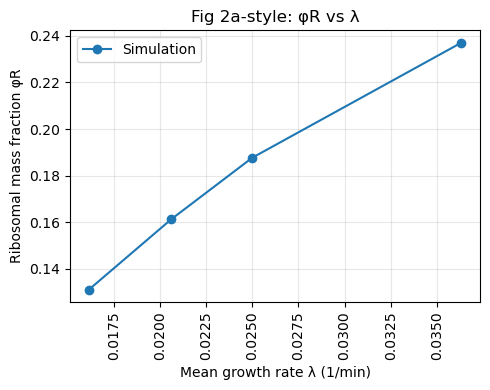

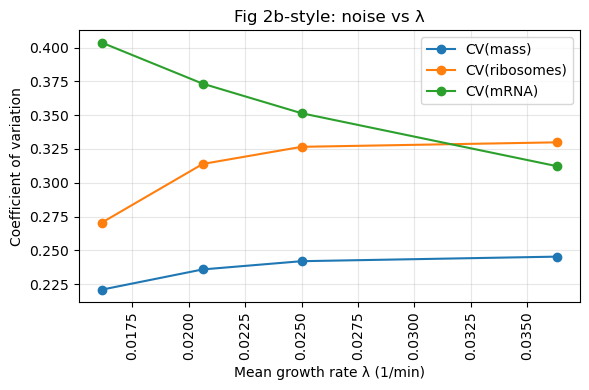

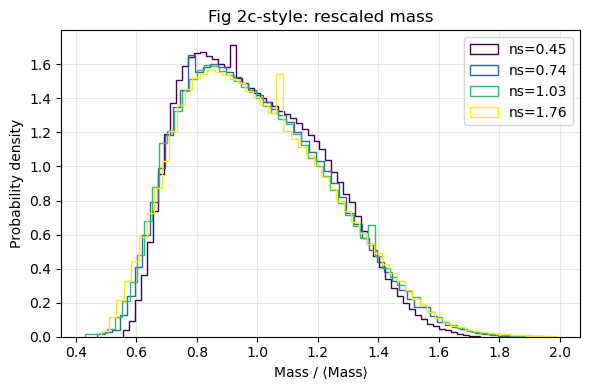

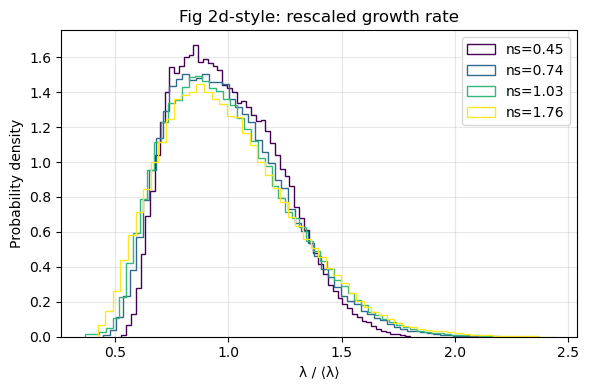

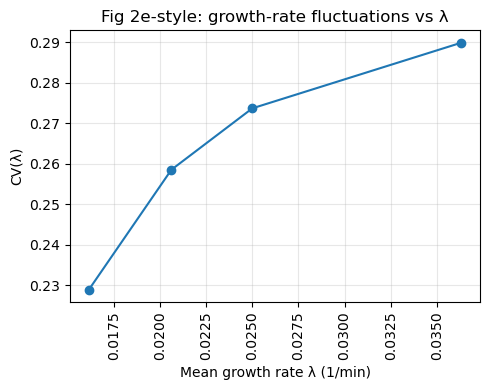

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import variation

# ===============================================================
#  FILES AND CONSTANTS
# ===============================================================
FILES_WITH_NS = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

# Parameters from your model (no extra SF, SF = 1)
NR = 7549.0     # ribosome mass factor
NX = 300.0      # non-ribosomal protein mass factor (q, et, em)
GMAX = 1260.0
KGAMMA = 7.0
MREF = 1e8      # used in lam = ttrate / Mref
BURN_IN_TIME = 1000.0  # minutes; adjust if needed


def load_arrow(path: str) -> pd.DataFrame:
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df: pd.DataFrame) -> np.ndarray:
    """
    mass(nr, r, rmm, rmt, rmq, rmr, zmm, zmt, zmq, zmr, nx, q, et, em)
      = nr * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
        + nx * (q + et + em)
    """
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_block = r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr
    prot_block = q + et + em

    mass = NR * ribo_block + NX * prot_block
    return mass

def compute_lambda(df: pd.DataFrame) -> np.ndarray:
    """
    λ(t) = ttrate / Mref, ttrate = (rmr+rmt+rmm+rmq) * gamma(a),
    gamma(a) = gmax * a / (Kgamma + a).
    Units: 1/min (no conversion to doublings/hour).
    """
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / (KGAMMA + a)

    active = (
        df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()

    ttrate = active * gamma
    lam = ttrate / MREF  # 1/min
    return lam

def total_ribosomes(df: pd.DataFrame) -> np.ndarray:
    return (
        df["r(t)"] + df["rmr(t)"] + df["rmt(t)"] +
        df["rmm(t)"] + df["rmq(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

def total_mrna(df: pd.DataFrame) -> np.ndarray:
    return (df["mm(t)"] + df["mt(t)"] + df["mq(t)"] + df["mr(t)"]).to_numpy()

def coeff_var(x: np.ndarray) -> float:
    x = np.asarray(x)
    m = x.mean()
    if m == 0:
        return np.nan
    return x.std(ddof=1) / m


summary = []
traj = {}

for fname, ns in FILES_WITH_NS:
    df = load_arrow(fname)
    t = df["timestamp"].to_numpy()

    lam = compute_lambda(df)       # 1/min
    mass = compute_mass(df)
    ribo = total_ribosomes(df)
    mrna = total_mrna(df)

    # ribosomal mass fraction φR = (ribosomal mass) / total mass
    ribo_mass = NR * ribo
    phiR_t = ribo_mass / mass

    # burn-in
    mask = t >= BURN_IN_TIME
    t_ss     = t[mask]
    lam_ss   = lam[mask]
    mass_ss  = mass[mask]
    ribo_ss  = ribo[mask]
    mrna_ss  = mrna[mask]
    phiR_ss  = phiR_t[mask]

    mean_lam   = lam_ss.mean()
    mean_mass  = mass_ss.mean()
    mean_ribo  = ribo_ss.mean()
    mean_mrna  = mrna_ss.mean()
    mean_phiR  = phiR_ss.mean()

    cv_mass  = coeff_var(mass_ss)
    cv_ribo  = coeff_var(ribo_ss)
    cv_mrna  = coeff_var(mrna_ss)
    cv_lam   = coeff_var(lam_ss)

    summary.append(dict(
        ns=ns,
        mean_lam=mean_lam,
        mean_mass=mean_mass,
        mean_ribo=mean_ribo,
        mean_mrna=mean_mrna,
        mean_phiR=mean_phiR,
        cv_mass=cv_mass,
        cv_ribo=cv_ribo,
        cv_mrna=cv_mrna,
        cv_lam=cv_lam
    ))

    traj[ns] = dict(
        t=t_ss,
        lam=lam_ss,
        mass=mass_ss,
        ribo=ribo_ss,
        mrna=mrna_ss,
        phiR=phiR_ss
    )

summary_df = pd.DataFrame(summary).sort_values("ns")
print(summary_df)

mean_lam   = summary_df["mean_lam"].to_numpy()
mean_phiR  = summary_df["mean_phiR"].to_numpy()
cv_mass    = summary_df["cv_mass"].to_numpy()
cv_ribo    = summary_df["cv_ribo"].to_numpy()
cv_mrna    = summary_df["cv_mrna"].to_numpy()
cv_lam     = summary_df["cv_lam"].to_numpy()

# ===============================================================
#  Fig 2a-style: φR vs mean λ
# ===============================================================
plt.figure(figsize=(5,4))
plt.plot(mean_lam, mean_phiR, "o-", label="Simulation")
plt.xticks(rotation=90)
plt.xlabel("Mean growth rate λ (1/min)")
plt.ylabel("Ribosomal mass fraction φR")
plt.title("Fig 2a-style: φR vs λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
#  Fig 2b-style: CV(mass), CV(ribo), CV(mRNA) vs λ
# ===============================================================
plt.figure(figsize=(6,4))
plt.plot(mean_lam, cv_mass, "o-", label="CV(mass)")
plt.plot(mean_lam, cv_ribo, "o-", label="CV(ribosomes)")
plt.plot(mean_lam, cv_mrna, "o-", label="CV(mRNA)")
plt.xlabel("Mean growth rate λ (1/min)")
plt.xticks(rotation=90)
plt.ylabel("Coefficient of variation")
plt.title("Fig 2b-style: noise vs λ")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
#  Fig 2c/d-style: rescaled mass and λ distributions
# ===============================================================
colors = plt.cm.viridis(np.linspace(0, 1, len(FILES_WITH_NS)))

# Rescaled mass
plt.figure(figsize=(6,4))
for (fname, ns), col in zip(FILES_WITH_NS, colors):
    m = traj[ns]["mass"]
    m_rescaled = m / m.mean()
    plt.hist(m_rescaled, bins=60, density=True,
             histtype="step", color=col, label=f"ns={ns:.2f}")
plt.xlabel("Mass / ⟨Mass⟩")
plt.ylabel("Probability density")
plt.title("Fig 2c-style: rescaled mass")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Rescaled λ
plt.figure(figsize=(6,4))
for (fname, ns), col in zip(FILES_WITH_NS, colors):
    lam_vals = traj[ns]["lam"]
    lam_rescaled = lam_vals / lam_vals.mean()
    plt.hist(lam_rescaled, bins=60, density=True,
             histtype="step", color=col, label=f"ns={ns:.2f}")
plt.xlabel("λ / ⟨λ⟩")
plt.ylabel("Probability density")
plt.title("Fig 2d-style: rescaled growth rate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
#  Fig 2e-style: CV(λ) vs mean λ
# ===============================================================
plt.figure(figsize=(5,4))
plt.plot(mean_lam, cv_lam, "o-", color="tab:blue")
plt.xlabel("Mean growth rate λ (1/min)")
plt.xticks(rotation=90)
plt.ylabel("CV(λ)")
plt.title("Fig 2e-style: growth-rate fluctuations vs λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
